# Python Lesson 24: Rotation, Reflection and Scaling Matrices

**Concept page:** `wiki/concepts/rotation-and-reflection-matrices.md` · **Area:** linear-algebra

**You will be able to:**
- build rotation/reflection/dilation/shear/projection matrices
- check det and inverse = transpose for rotations
- see their effect on a shape

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. The catalogue

In [2]:
def R(a): a=np.radians(a); return np.array([[np.cos(a),-np.sin(a)],[np.sin(a),np.cos(a)]])
mats={"identity":np.eye(2),"reflect x-axis":np.diag([1,-1]),"reflect y-axis":np.diag([-1,1]),"reflect origin":-np.eye(2),
      "dilate k=2":2*np.eye(2),"rotate 30":R(30),"shear s=1":np.array([[1,1],[0,1]]),"project x":np.diag([1,0])}
for k,m in mats.items(): print(f"{k:15s} det={np.linalg.det(m):6.2f}")

identity        det=  1.00
reflect x-axis  det= -1.00
reflect y-axis  det= -1.00
reflect origin  det=  1.00
dilate k=2      det=  4.00
rotate 30       det=  1.00
shear s=1       det=  1.00
project x       det=  0.00


## 2. Rotation facts

In [3]:
print(np.allclose(R(180),-np.eye(2)), np.allclose(R(360),np.eye(2)), np.allclose(np.linalg.inv(R(30)),R(30).T), np.allclose(R(30)@R(40),R(70)))

True True True True


## 3. Plot the effects

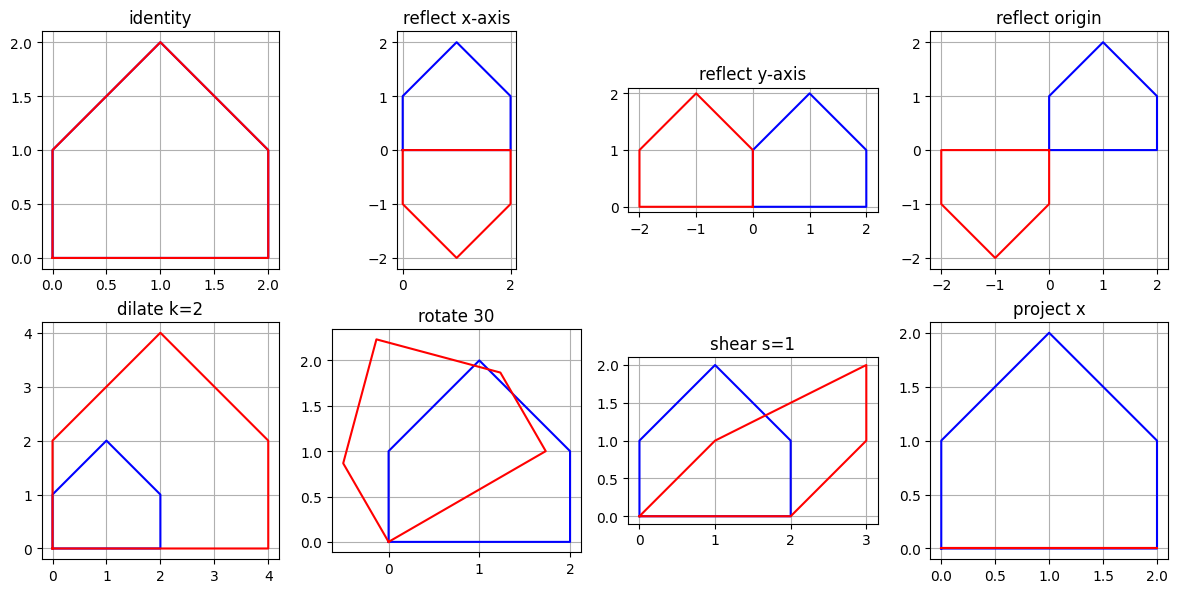

In [4]:
shape=np.array([[0,2,2,1,0,0],[0,0,1,2,1,0]],float)
fig,axs=plt.subplots(2,4,figsize=(12,6))
for ax,(k,m) in zip(axs.ravel(),mats.items()):
    ax.plot(*shape,'b-'); ax.plot(*(m@shape),'r-'); ax.set_title(k); ax.set_aspect('equal'); ax.grid(True)
plt.tight_layout(); plt.show()

## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 11 advanced p. 97–98: $S_{x'x}=\begin{pmatrix}1&0\\0&-1\end{pmatrix}$, $S_{y'y}=\begin{pmatrix}-1&0\\0&1\end{pmatrix}$, $S_O=-I$, and the inverse of a rotation is $\begin{pmatrix}\cos\alpha&\sin\alpha\\-\sin\alpha&\cos\alpha\end{pmatrix}$.

In [5]:
print(np.allclose(np.linalg.inv(R(25)),np.array([[np.cos(np.radians(25)),np.sin(np.radians(25))],[-np.sin(np.radians(25)),np.cos(np.radians(25))]])))

True


## Exercises

**Exercise 1.** Rotate (1,0) by 90 degrees and verify it lands on (0,1).

In [6]:
# your code here

**Exercise 2.** Show the composition reflect-x then reflect-y equals reflect-origin.

In [7]:
# your code here

## Solutions
*(Try the exercises first!)*

In [8]:
# Solution 1
assert np.allclose(R(90)@[1,0],[0,1])

In [9]:
# Solution 2
assert np.allclose(mats['reflect y-axis']@mats['reflect x-axis'],mats['reflect origin'])